In [14]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files


In [15]:

df = pd.read_csv('/content/drive/MyDrive/xo_data.csv')

In [16]:

df.shape


(100, 26)

In [17]:

X = df.drop('label', axis=1).values
y = df['label'].values


In [18]:

X.shape


(100, 25)

In [19]:

y.shape


(100,)

In [20]:

split    = int( 0.8 * len(X) )

X_train  = X[:split]
X_test   = X[split:]
y_train  = y[:split]
y_test   = y[split:]


In [21]:

list_losses = []
list_epochs_loss = []

def fit(X_train, y_train):
    learning_rate = 0.01

    n_samples, n_features = X_train.shape

    weights = np.zeros( n_features )
    bias = 0

    for _ in range(1000):
        for idx, x_i in enumerate(X_train):

            linear_product = np.dot(x_i, weights) + bias
            y_pred  = activation_function(    linear_product    )

            loss =  y_pred   -  y_train[idx]
            list_losses.append( loss  )

            update = learning_rate * ( y_pred   -  y_train[idx] )

            weights = weights - update * x_i
            bias    = bias - update

        avg = sum(list_losses) / len( list_losses  )
        list_epochs_loss.append( avg  )

    return weights, bias


In [22]:

def activation_function(z):
    return np.where( z>=0, 1, 0  )


In [23]:

def predict(X_test, weights, bias):
    linear_product = np.dot(X_test, weights) + bias
    y_pred  = activation_function(    linear_product    )
    return y_pred


In [24]:

def accuracy(y_true, y_pred):
    accuracy = np.sum(   y_true == y_pred   ) / len(  y_true  )
    return accuracy


In [25]:

weights, bias = fit(X_train, y_train)


In [26]:

weights


array([ 0.  , -0.04,  0.01,  0.05, -0.08,  0.05,  0.01, -0.02, -0.01,
        0.02,  0.05,  0.02, -0.14,  0.01,  0.07,  0.01,  0.02,  0.04,
       -0.02,  0.04,  0.02,  0.02,  0.02, -0.01, -0.06])

In [27]:

bias


np.float64(0.0)

In [28]:

y_pred = predict(X_test, weights, bias)


In [29]:

y_pred


array([0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0])

In [30]:

y_test


array([0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0])

In [31]:

print(  accuracy(y_pred, y_test)   )


1.0


In [32]:

x_vals = np.arange( len(list_epochs_loss) )


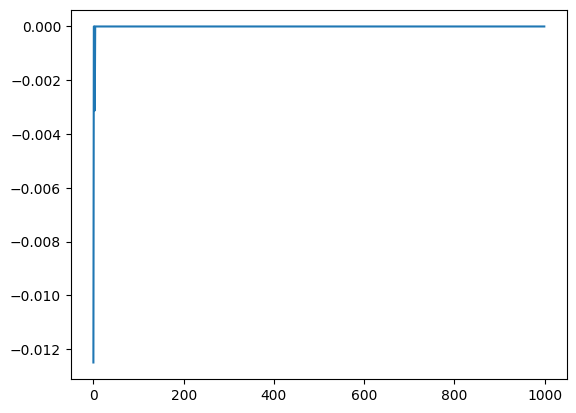

In [33]:

plt.plot(x_vals, list_epochs_loss)


In [34]:
weight_grid = weights.reshape( 5, 5 )

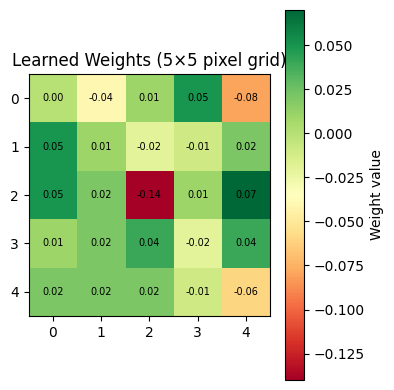

In [35]:
plt.figure(figsize=(4, 4))
plt.imshow(weight_grid, cmap='RdYlGn', interpolation='nearest')
plt.colorbar(label='Weight value')
plt.title('Learned Weights (5×5 pixel grid)')
plt.xticks(range(5))
plt.yticks(range(5))

for i in range(5):
    for j in range(5):
        plt.text(j, i, f'{weight_grid[i,j]:.2f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.show()

In [36]:

w_clean = [round(float(w), 6) for w in weights]
print( 'weights =', w_clean )
print( 'bias    =', round( float(bias), 6 ) )

weights = [0.0, -0.04, 0.01, 0.05, -0.08, 0.05, 0.01, -0.02, -0.01, 0.02, 0.05, 0.02, -0.14, 0.01, 0.07, 0.01, 0.02, 0.04, -0.02, 0.04, 0.02, 0.02, 0.02, -0.01, -0.06]
bias    = 0.0
